1. What is Anomaly Detection? Explain its types (point, contextual, and collective anomalies) with examples.

->  Anomaly Detection is the prosses of identify data points, patterns which is not  normal or common in dataset. these unusual patterns called outliers. 

i. Point Anomaly: A single data point  is anomalous compared to the rest of the dataset. 
Example: A credit card transaction of ₹5,00,000 in a dataset where the average transaction is ₹2,000. The single value deviates massively from the global distribution.

ii. Contextual Anomalies: A data point is anomalous only within a specific context (e.g., time or location), even though it may be normal in other contexts.
Example: 35 degree of temperature is unusual in january in kolkata.

iii. Collective Anomalies
A collection of data points is collectively anomalous even if individual points are not unusual on their own. The anomaly lies in the pattern or sequence.
Example: A single elevated heartbeat in an ECG may be normal, but a sustained sequence of abnormal beats for several seconds is a collective anomaly (arrhythmia).

2. "Compare Isolation Forest, DBSCAN, and Local Outlier Factor in terms of their approach and suitable use cases."

-> Isolation Forest - Tree based ensamble methord. it randomly selects a feature and spilt a value, partitioning the data recursivly, Anomalies are "few and different" - they need shorter path length tobe isolated, yielding a lower anomaly score. It is inharently unsupervised and doesn't need distence computation. Use cases - large scale fraud detecion, network intrusion detection etc.

DBSCAN - Density based clustering algorithm. It groups points that are closely packed useing two parameters - epsion and min- samples. Points in low-density regions that don't belong to any cluster are labelled noise (label = −1), which are treated as anomalies. Use cases: Spatial/geolocation data, datasets where normal data forms dense clusters of arbitrary shapes. Struggles with datasets of varying density and high-dimensional data.


Local Outlier Factor - Approach: Density-based method that computes the local reachability density of each point relative to its k-nearest neighbours. A point with an LOF score significantly greater than 1 has much lower local density than its neighbours — it is a local anomaly. Unlike DBSCAN, LOF detects anomalies relative to the local neighbourhood, making it effective even when density varies across the dataset.
Use cases: Datasets with clusters of varying density, medical sensor data, scenarios where a global threshold would miss local outliers. More computationally expensive (O(n²)) but more nuanced than Isolation Forest.

3. What are the key components of a Time Series? Explain each with one example.

-> 1. Trend

The long-term increase or decrease in the data over time, reflecting the underlying direction while ignoring short-term fluctuations.

Example: Monthly global average temperatures showing a gradual upward trend over decades due to climate change.

    2. Seasonality

Regular, repeating patterns that occur over a fixed, known period (daily, monthly, quarterly, yearly). These fluctuations are predictable and tied to the calendar.

Example: Ice cream sales peaking every summer (June–August) and dropping in winter — a clear annual seasonal cycle.

    3. Cyclicity

Fluctuations that repeat but over an irregular, non-fixed period, typically driven by economic or business conditions. Unlike seasonality, the duration and amplitude vary.

Example: Business cycles of economic expansion and recession in GDP data — booms and busts that recur but with irregular intervals of 4–10 years.

    4. Irregularity / Residual (Noise)

The unexplained, random variation left after removing trend, seasonality, and cyclicity. It is unpredictable and caused by unforeseen events.

Example: A sudden spike in a store's daily sales due to an unexpected viral social media post — it cannot be attributed to any seasonal or trend factor.


4. Define Stationarity in time series. How can you test and transform a non-stationary series into a stationary one?

-> A time series is stationary if its statistical properties remain constant over time — specifically: constant mean, constant variance, and autocovariance that depends only on lag (not on time). Stationarity is a fundamental assumption of classical models like ARIMA. Non-stationary series with trends, changing variance, or unit roots violate these assumptions and produce unreliable model estimates.
Testing for Stationarity:
Augmented Dickey-Fuller (ADF) Test: The most widely used test. Null hypothesis H0: the series has a unit root (non-stationary). If p-value < 0.05, reject H0 and conclude the series is stationary.
KPSS Test: H0 is stationarity (opposite of ADF). Using both tests together reduces the risk of incorrect conclusions.
Visual methods: Plotting the rolling mean and rolling standard deviation over time — if they drift, the series is non-stationary. A slowly decaying ACF plot also indicates non-stationarity.
Transformations to Achieve Stationarity:
Differencing (most common): Compute Yt = Xt − Xt−1 to remove a linear trend. Apply seasonal differencing (Yt = Xt − Xt−s) to remove seasonality. The 'd' parameter in ARIMA captures the number of regular differencing steps needed.
Log Transformation: Applying log(Xt) stabilises exponentially growing variance and converts multiplicative patterns to additive ones. Commonly used before fitting SARIMA on datasets like AirPassengers.
Box-Cox Transformation: A generalised power transformation that stabilises variance for a wider range of distributional shapes.
Removing deterministic trend: Fit and subtract a linear or polynomial trend line from the data.

5. Differentiate between AR, MA, ARIMA, SARIMA, and SARIMAX models in terms of structure and application.

-> AR — AutoRegressive Model AR(p)

Structure: The current value is regressed on its own past p values.

Xt = c + φ1Xt−1 + φ2Xt−2 + ... + φpXt−p + εt

Application: Series with autocorrelation — e.g., stock returns, temperature data. Requires a stationary series.
MA — Moving Average Model MA(q)

Structure: The current value is a linear combination of past q white noise error terms.

Xt = μ + εt + θ1εt−1 + ... + θqεt−q

Application: Series where shocks decay rapidly — e.g., modelling random disturbances in a manufacturing process.
ARIMA — AutoRegressive Integrated Moving Average ARIMA(p, d, q)

Structure: Combines AR and MA with d rounds of differencing to handle non-stationary series. It is the standard general-purpose univariate forecasting model.

Application: Monthly sales, electricity consumption, economic indicators — any univariate non-seasonal series requiring detrending.
SARIMA — Seasonal ARIMA SARIMA(p,d,q)(P,D,Q)s

Structure: Extends ARIMA by adding seasonal AR (P), seasonal differencing (D), and seasonal MA (Q) components at period s. For monthly data with annual seasonality, s = 12.

Application: Monthly airline passenger counts, quarterly retail sales, monthly energy demand — anything with clear, regular seasonal cycles.
SARIMAX — Seasonal ARIMA with eXogenous variables

Structure: Adds external predictor variables (exogenous regressors) to SARIMA. These are outside drivers that influence the target series.

Application: Electricity demand forecasting using weather (temperature, humidity) as exogenous inputs; retail demand forecasting with promotional calendars as regressors. The most powerful and realistic model when external drivers are available.


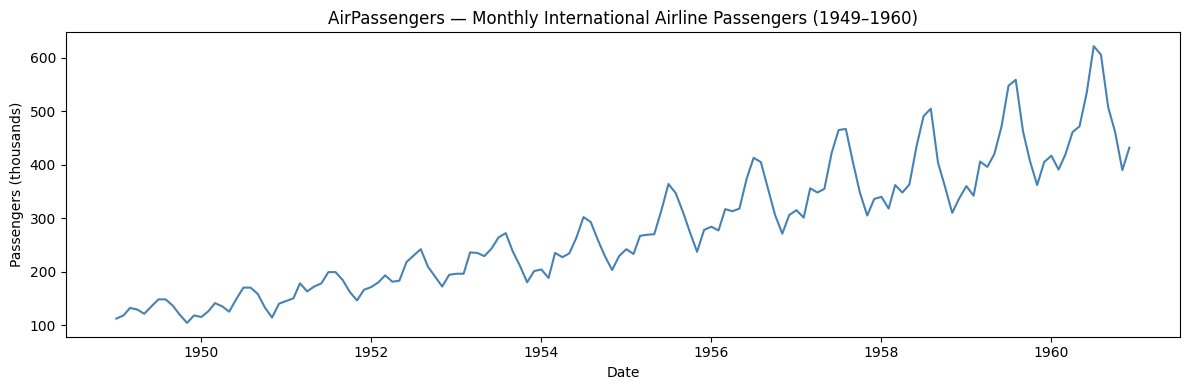

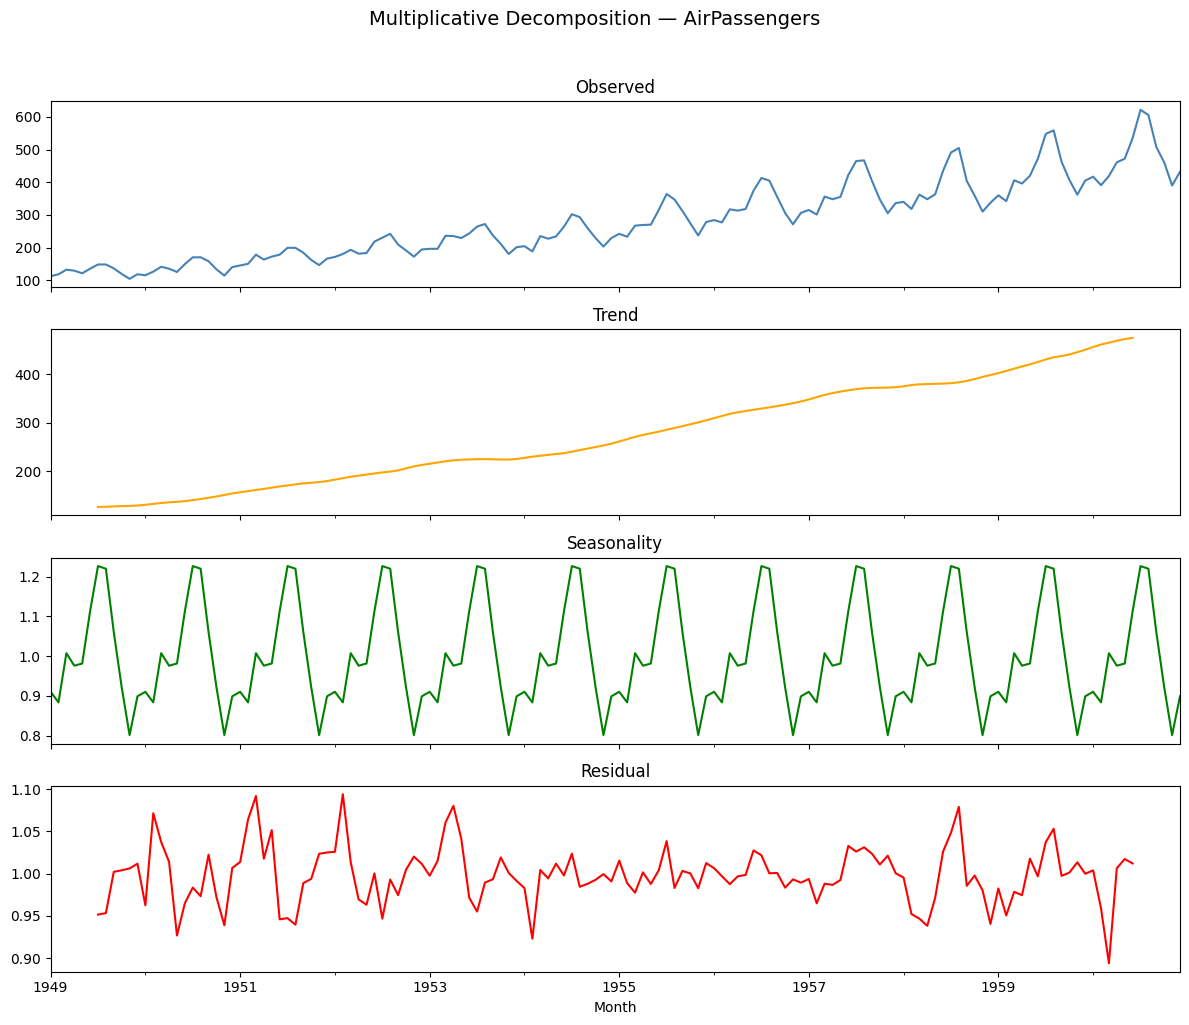

In [1]:
# 6. Load a time series dataset (e.g., AirPassengers), plot the original series, and decompose it into trend, seasonality, and residual components.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Load AirPassengers dataset
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv'
df = pd.read_csv(url, parse_dates=['Month'], index_col='Month')
df.columns = ['Passengers']

# Plot original series
plt.figure(figsize=(12, 4))
plt.plot(df, color='steelblue', linewidth=1.5)
plt.title('AirPassengers — Monthly International Airline Passengers (1949–1960)')
plt.xlabel('Date')
plt.ylabel('Passengers (thousands)')
plt.tight_layout()
plt.show()

# Multiplicative decomposition (variance grows with level)
decomposition = seasonal_decompose(df['Passengers'], model='multiplicative', period=12)

fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
decomposition.observed.plot(ax=axes[0], title='Observed', color='steelblue')
decomposition.trend.plot(ax=axes[1], title='Trend', color='orange')
decomposition.seasonal.plot(ax=axes[2], title='Seasonality', color='green')
decomposition.resid.plot(ax=axes[3], title='Residual', color='red')
plt.suptitle('Multiplicative Decomposition — AirPassengers', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

Anomalies detected: 26 out of 506


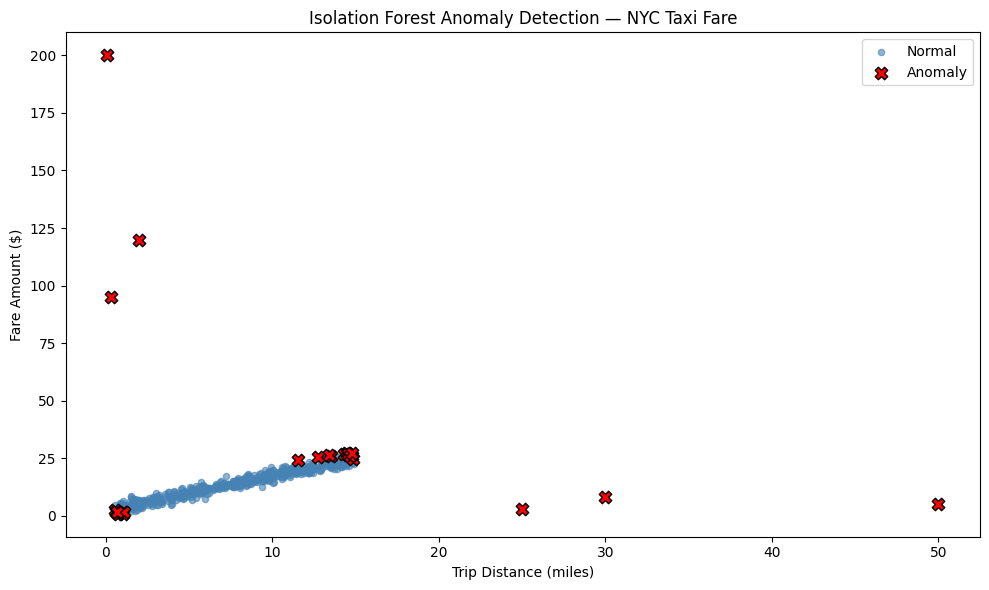

In [2]:
#7. Apply Isolation Forest on a numerical dataset (e.g., NYC Taxi Fare) to detect anomalies. Visualize the anomalies on a 2D scatter plot.

import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

# Synthetic NYC Taxi Fare-like data
np.random.seed(42)
n = 500
distance = np.random.uniform(0.5, 15, n)
fare = 2.5 + 1.5 * distance + np.random.normal(0, 1.5, n)

# Inject anomalies
anomaly_distance = np.array([0.3, 50, 2.0, 30, 0.1, 25])
anomaly_fare     = np.array([95,   5, 120,  8, 200,  3])

X_dist = np.concatenate([distance, anomaly_distance])
X_fare = np.concatenate([fare, anomaly_fare])
X = np.column_stack([X_dist, X_fare])

# Fit Isolation Forest
clf = IsolationForest(n_estimators=200, contamination=0.05, random_state=42)
labels = clf.fit_predict(X)   # -1 = anomaly, 1 = normal

normal_mask  = labels ==  1
anomaly_mask = labels == -1
print(f'Anomalies detected: {anomaly_mask.sum()} out of {len(X)}')

# Visualise
plt.figure(figsize=(10, 6))
plt.scatter(X[normal_mask, 0],  X[normal_mask, 1],
            c='steelblue', alpha=0.6, s=20, label='Normal')
plt.scatter(X[anomaly_mask, 0], X[anomaly_mask, 1],
            c='red', s=80, marker='X', edgecolors='black', label='Anomaly')
plt.xlabel('Trip Distance (miles)')
plt.ylabel('Fare Amount ($)')
plt.title('Isolation Forest Anomaly Detection — NYC Taxi Fare')
plt.legend()
plt.tight_layout()
plt.show()

                                     SARIMAX Results                                      
Dep. Variable:                           log_pass   No. Observations:                  144
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                 218.517
Date:                            Fri, 19 Jun 2026   AIC                           -427.035
Time:                                    03:01:27   BIC                           -413.224
Sample:                                01-01-1949   HQIC                          -421.428
                                     - 12-01-1960                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1014      0.203      0.501      0.617      -0.296       0.499
ma.L1         -0.5548      0.179   

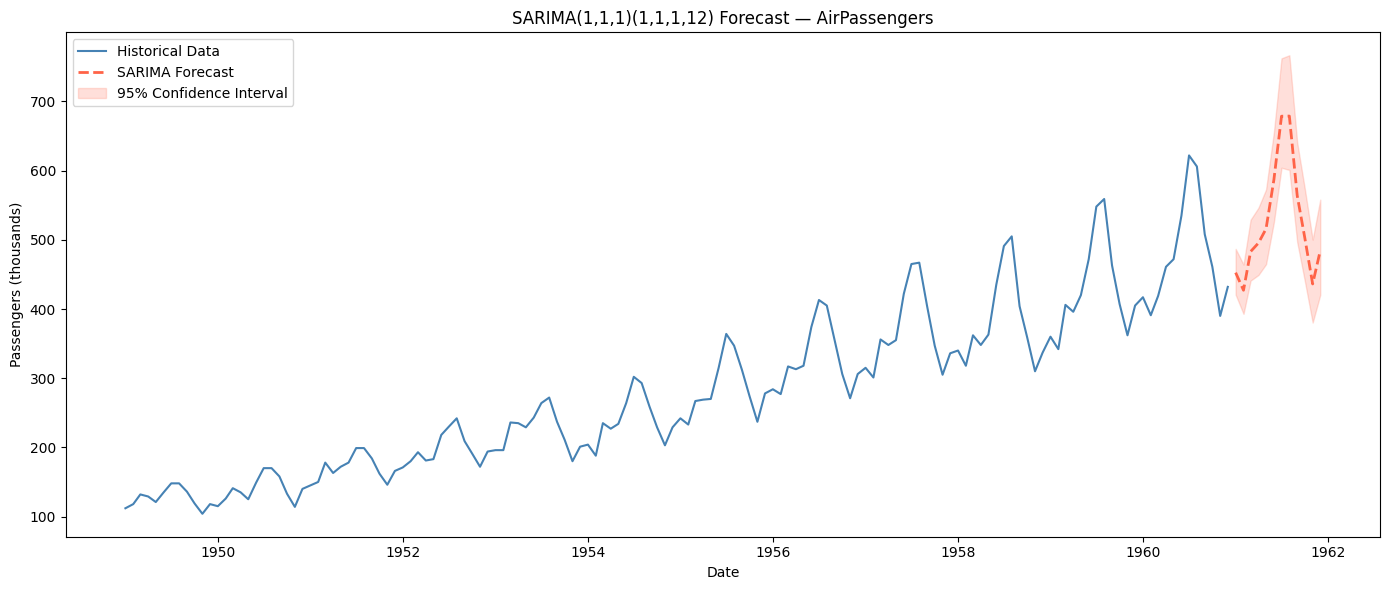

In [3]:
# 8. Train a SARIMA model on the monthly airline passengers dataset. Forecast the next 12 months and visualize the results.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Load data
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv'
df = pd.read_csv(url, parse_dates=['Month'], index_col='Month')
df.columns = ['Passengers']
df.index.freq = 'MS'

# Log-transform to stabilise variance
df['log_pass'] = np.log(df['Passengers'])

# SARIMA(1,1,1)(1,1,1,12) — classic configuration for AirPassengers
model = SARIMAX(df['log_pass'],
                order=(1, 1, 1),
                seasonal_order=(1, 1, 1, 12),
                enforce_stationarity=False,
                enforce_invertibility=False)
results = model.fit(disp=False)
print(results.summary())

# Forecast next 12 months
forecast_obj  = results.get_forecast(steps=12)
forecast_log  = forecast_obj.predicted_mean
conf_int_log  = forecast_obj.conf_int(alpha=0.05)

# Back-transform from log scale
forecast_vals = np.exp(forecast_log)
lower         = np.exp(conf_int_log.iloc[:, 0])
upper         = np.exp(conf_int_log.iloc[:, 1])

# Plot
plt.figure(figsize=(14, 6))
plt.plot(df['Passengers'], label='Historical Data', color='steelblue', linewidth=1.5)
plt.plot(forecast_vals, label='SARIMA Forecast', color='tomato', linewidth=2, linestyle='--')
plt.fill_between(forecast_vals.index, lower, upper,
                 color='tomato', alpha=0.2, label='95% Confidence Interval')
plt.title('SARIMA(1,1,1)(1,1,1,12) Forecast — AirPassengers')
plt.xlabel('Date')
plt.ylabel('Passengers (thousands)')
plt.legend()
plt.tight_layout()
plt.show()

Total: 320 | Outliers: 20 | Inliers: 300


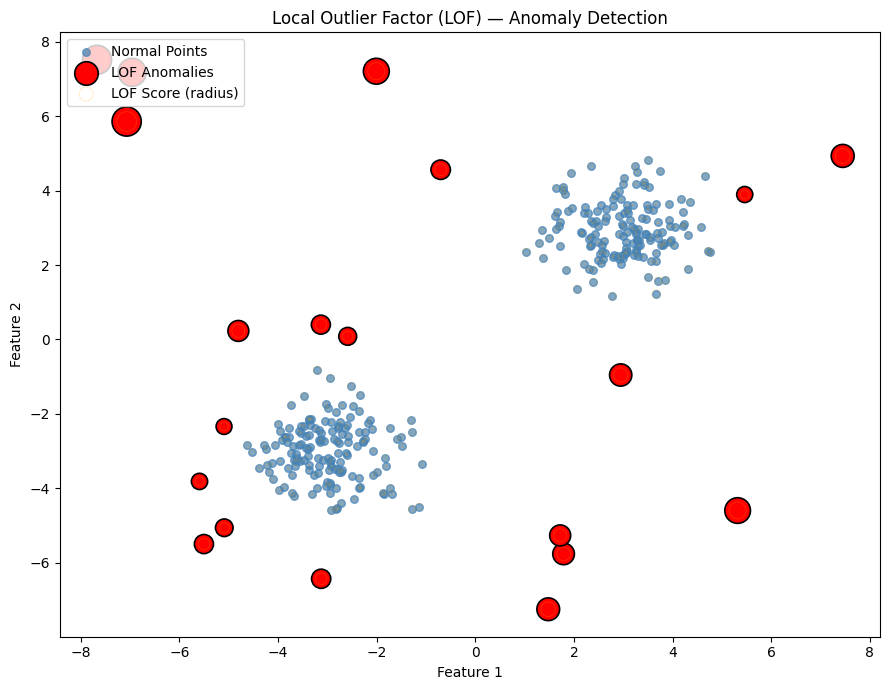

In [4]:
# 9.  Apply Local Outlier Factor (LOF) on any numerical dataset to detect anomalies and visualize them using matplotlib.

import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import LocalOutlierFactor
from sklearn.datasets import make_blobs

np.random.seed(42)
# Two dense clusters + scattered outliers
X_normal, _ = make_blobs(n_samples=300, centers=[[-3,-3],[3,3]],
                          cluster_std=0.8, random_state=42)
X_outliers  = np.random.uniform(low=-8, high=8, size=(20, 2))
X = np.vstack([X_normal, X_outliers])

# Fit LOF
lof    = LocalOutlierFactor(n_neighbors=20, contamination=0.06)
labels = lof.fit_predict(X)
scores = -lof.negative_outlier_factor_   # higher = more anomalous

print(f'Total: {len(X)} | Outliers: {(labels==-1).sum()} | Inliers: {(labels==1).sum()}')

normal_mask  = labels ==  1
outlier_mask = labels == -1

plt.figure(figsize=(9, 7))
plt.scatter(X[normal_mask, 0],  X[normal_mask, 1],
            c='steelblue', s=30, alpha=0.7, label='Normal Points')
plt.scatter(X[outlier_mask, 0], X[outlier_mask, 1],
            c='red', s=scores[outlier_mask]*60, marker='o',
            edgecolors='black', linewidths=1.2, label='LOF Anomalies')

# Overlay LOF score as circle radius for all points
radius = (scores - scores.min()) / (scores.max() - scores.min()) * 200
plt.scatter(X[:, 0], X[:, 1], s=radius, edgecolors='orange',
            facecolors='none', linewidths=0.5, alpha=0.3, label='LOF Score (radius)')

plt.title('Local Outlier Factor (LOF) — Anomaly Detection')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

Anomalies detected: 58


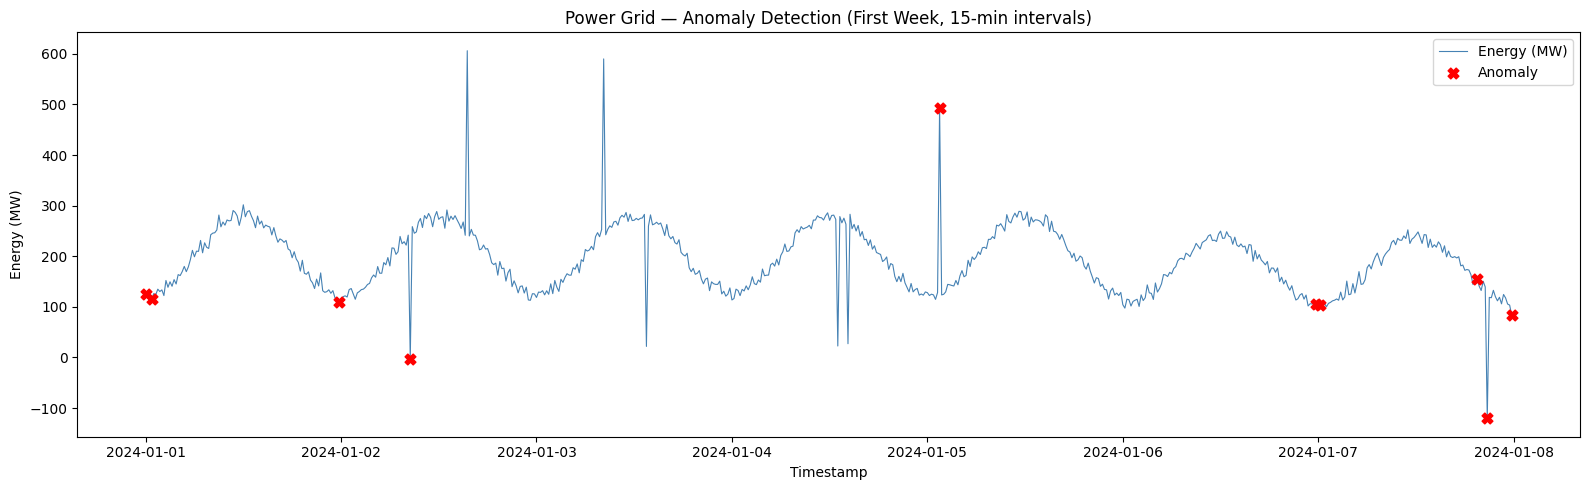

SARIMAX Test MAPE: 6.53%


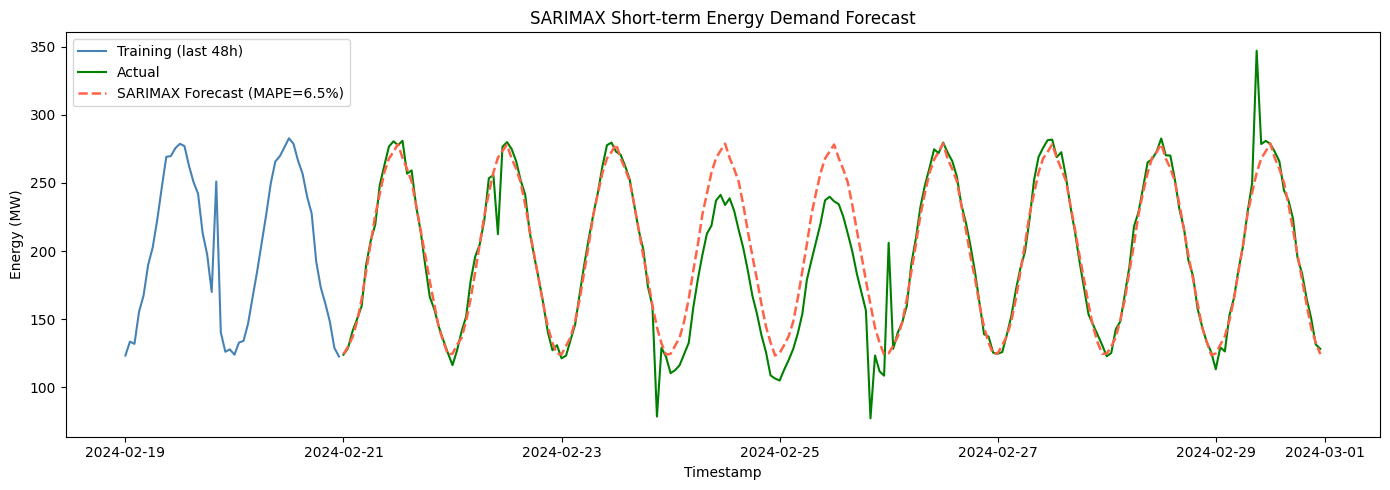

In [6]:
# 10. Real-time Power Grid Monitoring — Data Science Workflow

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_percentage_error

# ── 1. SIMULATE POWER GRID DATA (15-min intervals, 60 days) ──
np.random.seed(42)
n = 60 * 96
timestamps = pd.date_range('2024-01-01', periods=n, freq='15min')

hour_of_day    = timestamps.hour + timestamps.minute / 60
day_of_week    = timestamps.dayofweek
daily_cycle    = 200 + 80 * np.sin(2 * np.pi * (hour_of_day - 6) / 24)
weekly_pattern = np.where(day_of_week >= 5, 0.85, 1.0)
temperature    = 25 + 10 * np.sin(2 * np.pi * (hour_of_day - 14) / 24) + np.random.normal(0, 2, n)
weather_effect = 0.5 * np.maximum(temperature - 22, 0)
energy_usage   = (daily_cycle * weekly_pattern) + weather_effect + np.random.normal(0, 8, n)

# Inject anomalies
anomaly_idx = np.random.choice(n, size=30, replace=False)
energy_usage = np.array(energy_usage)  # force numpy array before mutation
energy_usage[anomaly_idx] += np.random.choice([-250, 350], size=30)

df = pd.DataFrame({
    'energy_mw': energy_usage,
    'temperature': temperature,
    'hour': hour_of_day,
    'day_of_week': day_of_week
}, index=timestamps)

# ── 2. ANOMALY DETECTION ──
features = ['energy_mw', 'temperature', 'hour', 'day_of_week']
X_scaled = StandardScaler().fit_transform(df[features])

iso = IsolationForest(n_estimators=200, contamination=0.01, random_state=42)
df['anomaly'] = iso.fit_predict(X_scaled)
print(f"Anomalies detected: {(df['anomaly']==-1).sum()}")

# Plot first week
week = df.iloc[:96*7]
plt.figure(figsize=(16, 5))
plt.plot(week.index, week['energy_mw'], color='steelblue', linewidth=0.8, label='Energy (MW)')
anom = week[week['anomaly'] == -1]
plt.scatter(anom.index, anom['energy_mw'], color='red', s=60, marker='X', label='Anomaly', zorder=5)
plt.title('Power Grid — Anomaly Detection (First Week, 15-min intervals)')
plt.xlabel('Timestamp')
plt.ylabel('Energy (MW)')
plt.legend()
plt.tight_layout()
plt.show()

# ── 3. SARIMAX FORECASTING (hourly aggregation) ──
df_hourly = df['energy_mw'].resample('h').mean()
df_temp   = df['temperature'].resample('h').mean()

split = int(len(df_hourly) * 0.85)
train_y, test_y         = df_hourly.iloc[:split], df_hourly.iloc[split:]
train_exog, test_exog   = df_temp.iloc[:split].values.reshape(-1,1), \
                          df_temp.iloc[split:].values.reshape(-1,1)

model = SARIMAX(train_y, exog=train_exog,
                order=(1,1,1), seasonal_order=(1,1,1,24),
                enforce_stationarity=False, enforce_invertibility=False)
fit = model.fit(disp=False, maxiter=100)

forecast = fit.forecast(steps=len(test_y), exog=test_exog)
mape = mean_absolute_percentage_error(test_y, forecast) * 100
print(f'SARIMAX Test MAPE: {mape:.2f}%')

# Plot forecast
plt.figure(figsize=(14, 5))
plt.plot(train_y.index[-48:], train_y.iloc[-48:], color='steelblue', label='Training (last 48h)')
plt.plot(test_y.index, test_y, color='green', label='Actual')
plt.plot(forecast.index, forecast, color='tomato', linestyle='--',
         linewidth=1.8, label=f'SARIMAX Forecast (MAPE={mape:.1f}%)')
plt.title('SARIMAX Short-term Energy Demand Forecast')
plt.xlabel('Timestamp')
plt.ylabel('Energy (MW)')
plt.legend()
plt.tight_layout()
plt.show()
